# CP260 Robotic Perception — Final Project
## Metric-Semantic 3D Reconstruction

**Course:** CP260-2026  
**Due Date:** May 4, 2026  

---

## Project Overview
This notebook implements a **Metric-Semantic Reconstruction** pipeline for a desktop scene.  
Given **16 posed RGB images** of a PC tower, the system:
1. Detects semantic objects (sockets) using **GroundingDINO** (zero-shot detection)
2. Collects 2D detections across multiple views
3. **Triangulates** rays from multiple camera poses to estimate 3D positions
4. Fits **Oriented Bounding Boxes (OBBs)** for each entity
5. Outputs the final `answer.json` in the required submission format

**Entities detected:**
- `vga_socket` — VGA port (GT provided for validation)
- `ethernet_socket` — RJ45 ethernet port
- `power_socket` — IEC C14 power inlet


---
## Step 1: Check GPU & Environment

In [1]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  No GPU detected! Go to Runtime → Change Runtime Type → T4 GPU")


PyTorch version: 2.10.0+cu128
CUDA available:  True
GPU: Tesla T4
GPU Memory: 15.6 GB


---
## Step 2: Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive mounted!")


Mounted at /content/drive
✅ Google Drive mounted!


---
## Step 3: Load Dataset
Load 16 posed images, camera poses, and intrinsics from Google Drive.

> **Note:** Make sure your dataset is at:  
> `My Drive/Robotic Perception Project/Data/Data/`  
> containing: `frame_000319.png` ... `frame_000531.png`, `poses.json`, `intrinsic.json`


In [3]:
import os, shutil, json
import numpy as np

# ── Paths ──────────────────────────────────────────────────────────────
DRIVE_PATH = '/content/drive/MyDrive/Robotic Perception Project/Data/Data'
LOCAL_PATH = '/content/dataset'

# Copy to local for faster I/O
if not os.path.exists(LOCAL_PATH):
    shutil.copytree(DRIVE_PATH, LOCAL_PATH)
    print(f"✅ Dataset copied to {LOCAL_PATH}")
else:
    print(f"✅ Dataset already at {LOCAL_PATH}")

# ── Frame numbers ───────────────────────────────────────────────────────
frame_numbers = [319,333,353,359,365,371,390,400,426,449,461,468,471,496,515,531]
print(f"\n📷 Total frames: {len(frame_numbers)}")

# ── Load poses ──────────────────────────────────────────────────────────
with open(f'{LOCAL_PATH}/poses.json') as f:
    all_poses = json.load(f)

# Convert to numpy arrays (camera-to-world 4x4 matrices)
poses = {}
for fn in frame_numbers:
    key = str(fn)
    poses[fn] = np.array(all_poses[key])
print(f"✅ Loaded {len(poses)} poses")

# ── Camera intrinsics ───────────────────────────────────────────────────
with open(f'{LOCAL_PATH}/intrinsic.json') as f:
    intr = json.load(f)

cam = intr['camera_matrix']
K = np.array(cam)
IMG_W = intr['image_width']   # 2560
IMG_H = intr['image_height']  # 1440
print(f"✅ Intrinsics loaded | Image size: {IMG_W}x{IMG_H}")
print(f"   fx={K[0,0]:.2f}, fy={K[1,1]:.2f}, cx={K[0,2]:.2f}, cy={K[1,2]:.2f}")

# Verify all image files exist
missing = [fn for fn in frame_numbers if not os.path.exists(f'{LOCAL_PATH}/frame_{fn:06d}.png')]
if missing:
    print(f"⚠️  Missing frames: {missing}")
else:
    print(f"✅ All {len(frame_numbers)} image files found!")


✅ Dataset copied to /content/dataset

📷 Total frames: 16
✅ Loaded 16 poses
✅ Intrinsics loaded | Image size: 2560x1440
   fx=1477.01, fy=1480.44, cx=1298.25, cy=686.82
✅ All 16 image files found!


---
## Step 4: Visualize Sample Frames

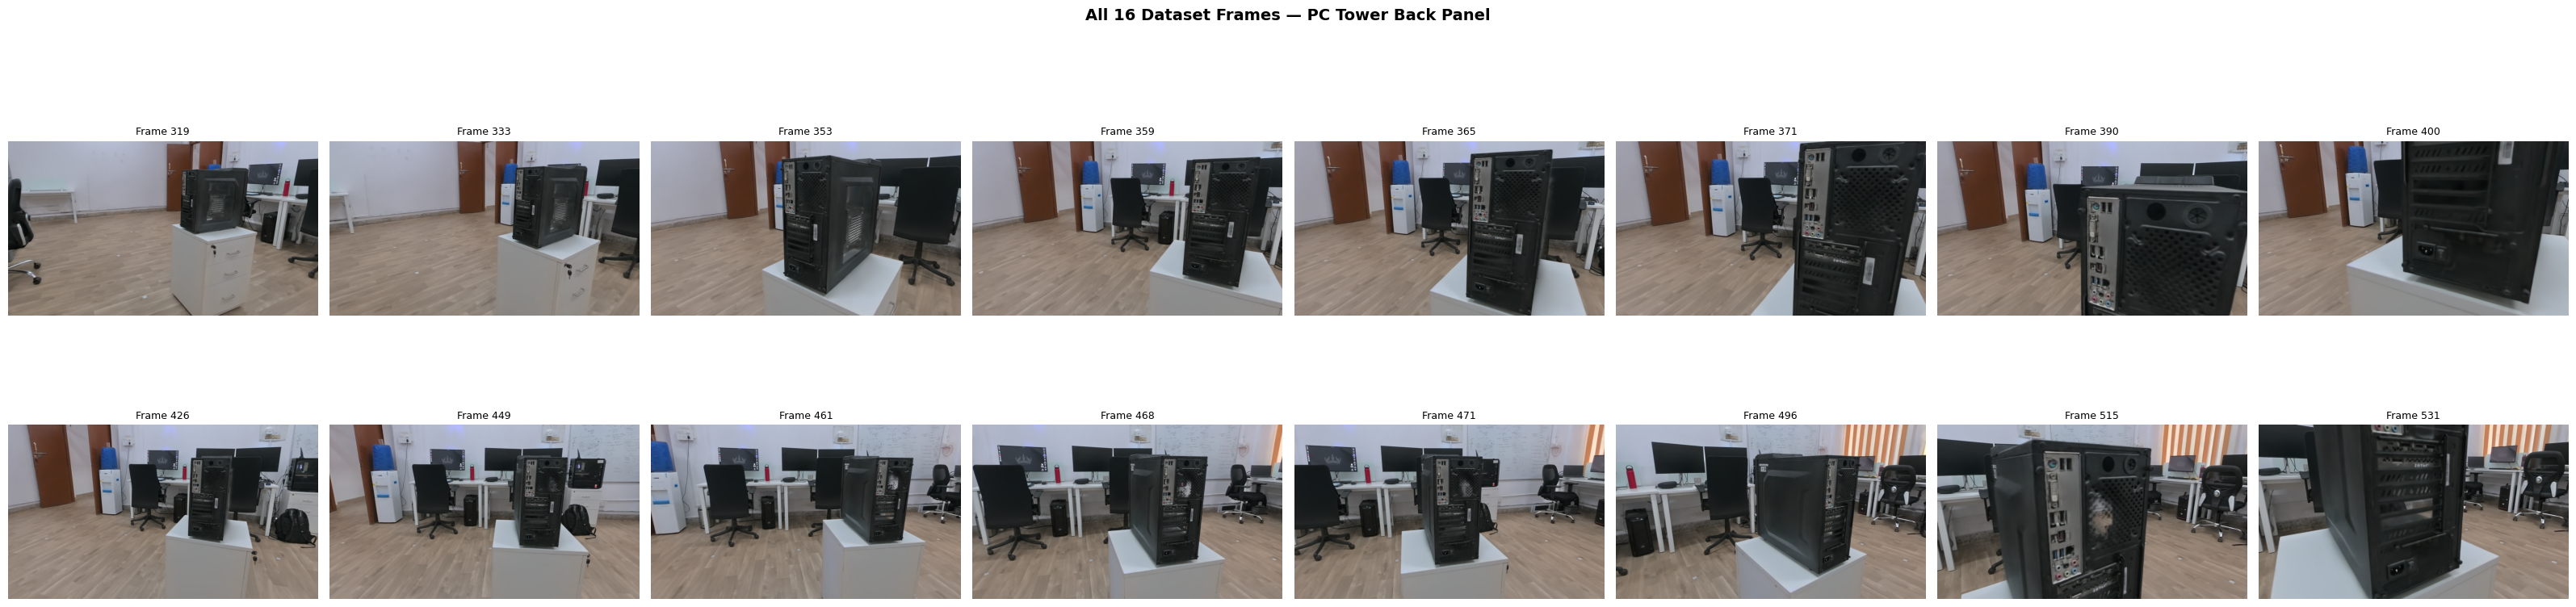

✅ Saved sample_frames.png


In [4]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 8, figsize=(32, 9))
axes = axes.flatten()

for i, fn in enumerate(frame_numbers):
    img = Image.open(f"{LOCAL_PATH}/frame_{fn:06d}.png")
    axes[i].imshow(img)
    axes[i].set_title(f"Frame {fn}", fontsize=9)
    axes[i].axis('off')

plt.suptitle("All 16 Dataset Frames — PC Tower Back Panel", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/sample_frames.png', dpi=80, bbox_inches='tight')
plt.show()
print("✅ Saved sample_frames.png")


---
## Step 5: Install Dependencies
Install GroundingDINO and Open3D.

In [5]:
print("Installing packages... (this takes ~2 minutes)")
!pip install -q open3d opencv-python-headless
!pip install -q transformers timm supervision
print("✅ All packages installed!")


Installing packages... (this takes ~2 minutes)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 75.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.1 MB/s eta 0:00:00
✅ All packages installed!


---
## Step 6: Load GroundingDINO Model
Zero-shot object detection using text prompts — no training needed!


In [6]:
import torch
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

print("Loading GroundingDINO...")
MODEL_ID = "IDEA-Research/grounding-dino-tiny"
gdino_processor = AutoProcessor.from_pretrained(MODEL_ID)
gdino_model = AutoModelForZeroShotObjectDetection.from_pretrained(MODEL_ID).to(device)
print("✅ GroundingDINO loaded!")


Using device: cuda
Loading GroundingDINO...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

The image processor of type `GroundingDinoImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/689M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/990 [00:00<?, ?it/s]

✅ GroundingDINO loaded!


---
## Step 7: Define Detection Functions

In [11]:
from PIL import Image as PILImage
import torch, numpy as np

# Text prompts for each entity
TEXT_PROMPTS = {
    "vga_socket":      "VGA port. D-sub connector.",
    "ethernet_socket": "RJ45 ethernet port. LAN socket.",
    "power_socket":    "IEC C14 power inlet. power socket.",
}

def detect_objects(image_path, text_prompt, threshold=0.20):
    """Run GroundingDINO on one image with one text prompt."""
    image = PILImage.open(image_path).convert("RGB")
    inputs = gdino_processor(
        images=image,
        text=text_prompt,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = gdino_model(**inputs)

    target_sizes = torch.tensor([image.size[::-1]])

    # ── Fixed: use threshold instead of box_threshold ──
    results = gdino_processor.post_process_grounded_object_detection(
        outputs,
        inputs['input_ids'],
        threshold=threshold,
        target_sizes=target_sizes
    )[0]

    return image, results['boxes'], results['scores'], results['labels']


def get_best_detection(image_path, text_prompt, threshold=0.20):
    """Return (center_pixel, box_size, score) of highest-confidence detection."""
    image, boxes, scores, labels = detect_objects(image_path, text_prompt, threshold)
    if len(scores) == 0:
        return None, None, 0.0
    best = scores.argmax().item()
    box = boxes[best].cpu().numpy()
    cx = (box[0] + box[2]) / 2.0
    cy = (box[1] + box[3]) / 2.0
    w  = box[2] - box[0]
    h  = box[3] - box[1]
    return np.array([cx, cy]), np.array([w, h]), scores[best].item()

print("Detection functions defined!")

Detection functions defined!


---
## Step 8: Test Detection on a Single Frame
Validate that GroundingDINO can find the sockets.

/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:91: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


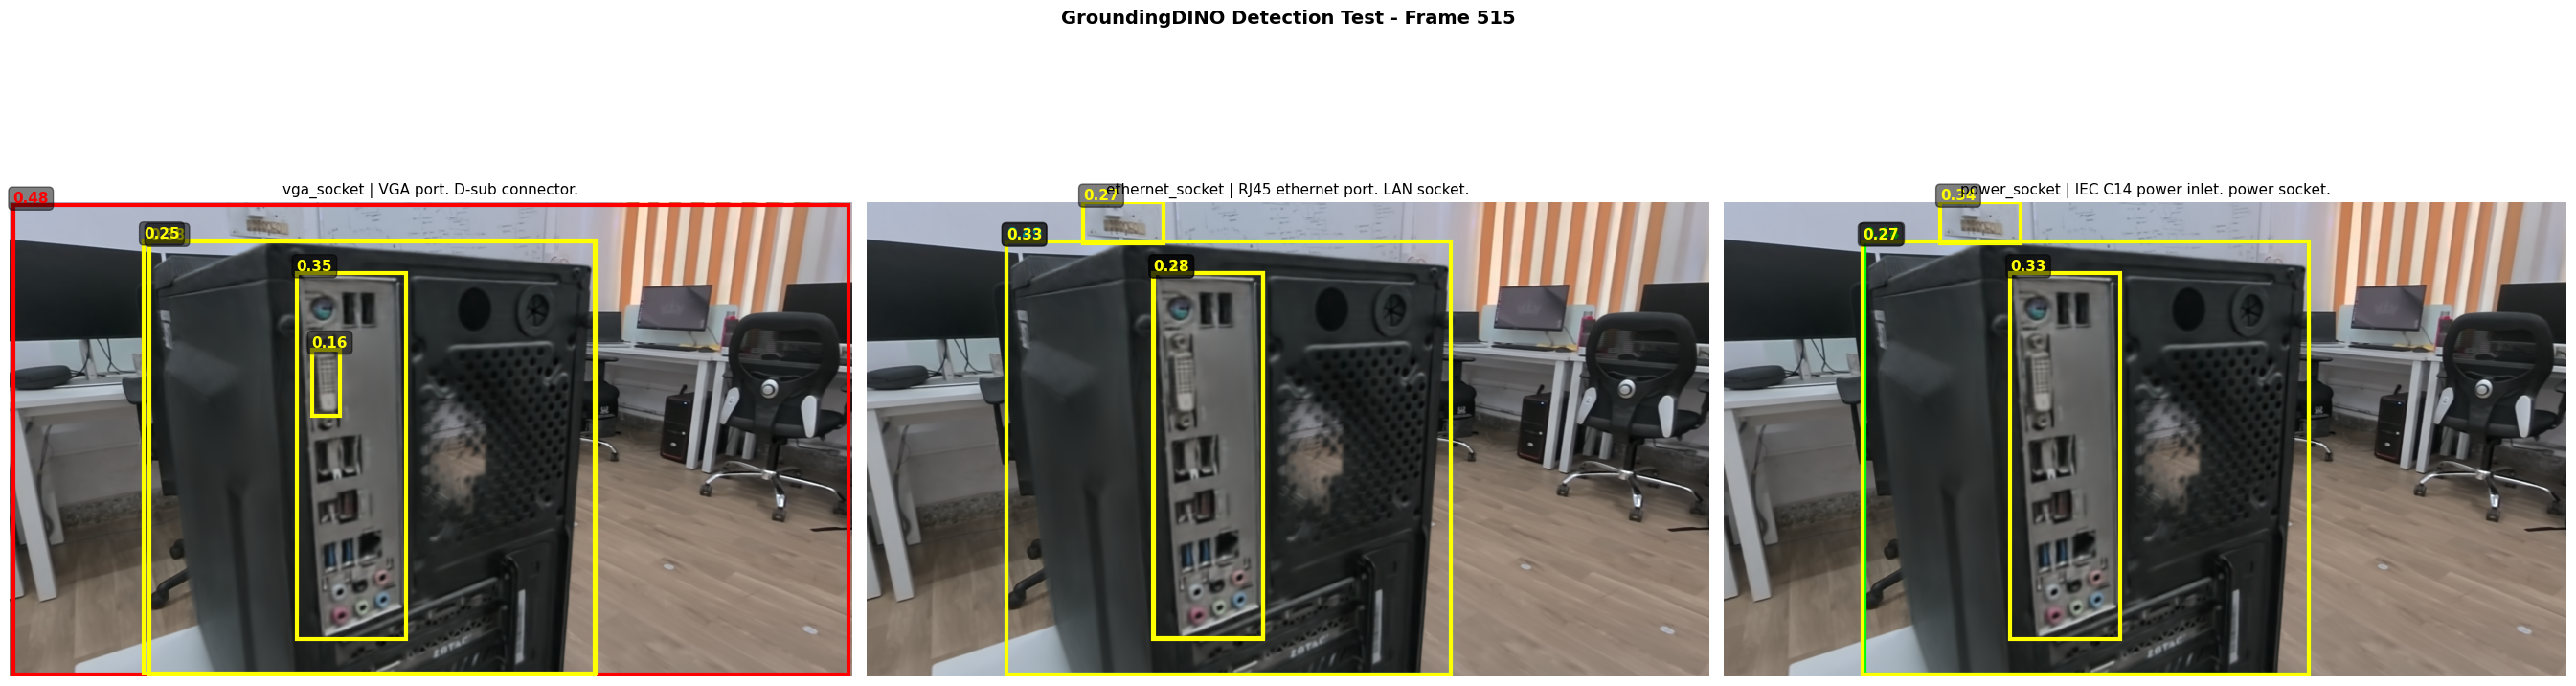

Detection test complete!


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Test on frame 515 (good close-up of back panel)
test_frame = 515
test_path  = f"{LOCAL_PATH}/frame_{test_frame:06d}.png"

fig, axes = plt.subplots(1, 3, figsize=(27, 9))
colors = ['red', 'cyan', 'lime']

for i, (entity, prompt) in enumerate(TEXT_PROMPTS.items()):
    image, boxes, scores, labels = detect_objects(test_path, prompt, threshold=0.15)
    img_arr = np.array(image)
    ax = axes[i]
    ax.imshow(img_arr)

    for j, (box, score) in enumerate(zip(boxes, scores)):
        x1, y1, x2, y2 = box.cpu().numpy()
        col = colors[i] if j == scores.argmax().item() else 'yellow'
        rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                                   linewidth=3, edgecolor=col, facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1-8, str(round(score.item(), 2)), color=col,
                fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))

    ax.set_title(entity + " | " + prompt[:35], fontsize=11)
    ax.axis('off')

plt.suptitle("GroundingDINO Detection Test - Frame " + str(test_frame), fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/test_detections.png', dpi=80, bbox_inches='tight')
plt.show()
print("Detection test complete!")

---
## Step 9: Collect Detections Across All 16 Frames
Run detection on every frame for every entity.


In [13]:
print("Collecting detections across all 16 frames...")
print("=" * 60)

all_detections = {entity: [] for entity in TEXT_PROMPTS}

for fn in frame_numbers:
    img_path = f"{LOCAL_PATH}/frame_{fn:06d}.png"
    for entity, prompt in TEXT_PROMPTS.items():
        center, size, score = get_best_detection(img_path, prompt, threshold=0.15)
        if center is not None and score > 0.10:
            all_detections[entity].append({
                'frame':        fn,
                'pixel_center': center,   # (cx, cy) in pixels
                'pixel_size':   size,     # (w, h) in pixels
                'score':        score,
                'pose':         poses[fn] # 4x4 c2w matrix
            })
            print(f"  ✅ Frame {fn:3d} | {entity:20s} | score={score:.3f} | center=({center[0]:.0f},{center[1]:.0f})")
        else:
            print(f"  ❌ Frame {fn:3d} | {entity:20s} | not detected")

print("\n" + "="*60)
print("DETECTION SUMMARY:")
for entity, dets in all_detections.items():
    print(f"  {entity}: {len(dets)}/16 frames detected")


  ✅ Frame 319 | vga_socket           | score=0.442 | center=(1701,489)
  ✅ Frame 319 | ethernet_socket      | score=0.619 | center=(1862,132)
  ✅ Frame 319 | power_socket         | score=0.718 | center=(1862,132)
  ✅ Frame 333 | vga_socket           | score=0.522 | center=(1818,532)
  ✅ Frame 333 | ethernet_socket      | score=0.590 | center=(1657,130)
  ✅ Frame 333 | power_socket         | score=0.687 | center=(1657,130)
  ✅ Frame 353 | vga_socket           | score=0.502 | center=(1491,688)
  ✅ Frame 353 | ethernet_socket      | score=0.590 | center=(1491,688)
  ✅ Frame 353 | power_socket         | score=0.523 | center=(1491,688)
  ✅ Frame 359 | vga_socket           | score=0.482 | center=(1278,719)
  ✅ Frame 359 | ethernet_socket      | score=0.610 | center=(1143,111)
  ✅ Frame 359 | power_socket         | score=0.707 | center=(1143,111)
  ✅ Frame 365 | vga_socket           | score=0.486 | center=(1279,720)
  ✅ Frame 365 | ethernet_socket      | score=0.636 | center=(1054,102)
  ✅ Fr

---
## Step 10: 3D Localization via Multi-View Ray Triangulation
Cast a ray from each camera through each 2D detection center.  
Find the 3D point minimizing distance to all rays (least-squares).


In [14]:
import numpy as np

def pixel_to_ray(pixel, pose_c2w, K):
    """Get ray origin + direction in world frame for a pixel."""
    cx, cy = pixel
    # Unproject pixel to normalized camera coords
    x_cam = (cx - K[0,2]) / K[0,0]
    y_cam = (cy - K[1,2]) / K[1,1]
    dir_cam = np.array([x_cam, y_cam, 1.0])
    dir_cam /= np.linalg.norm(dir_cam)

    R = pose_c2w[:3, :3]
    t = pose_c2w[:3, 3]

    ray_origin    = t
    ray_direction = R @ dir_cam
    ray_direction /= np.linalg.norm(ray_direction)
    return ray_origin, ray_direction


def triangulate_rays(detections, K, min_score=0.15):
    """Least-squares triangulation: find 3D point closest to all rays."""
    high_conf = [d for d in detections if d['score'] >= min_score]
    if len(high_conf) < 2:
        high_conf = detections  # use all if not enough

    # Build linear system: minimize ||Ax - b||
    A = []
    b = []
    for det in high_conf:
        o, d = pixel_to_ray(det['pixel_center'], det['pose'], K)
        # Constraint: (I - d*d^T)(x - o) = 0  → (I - d*d^T)x = (I - d*d^T)o
        proj = np.eye(3) - np.outer(d, d)
        A.append(proj)
        b.append(proj @ o)

    A = np.vstack(A)
    b = np.concatenate(b)
    center_3d, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    return center_3d


def estimate_extent_from_detections(detections, center_3d, K, default_extent):
    """Estimate OBB extent from average pixel size and depth."""
    depths = []
    pixel_sizes = []
    for det in detections:
        R_inv = det['pose'][:3,:3].T
        t_inv = -R_inv @ det['pose'][:3, 3]
        p_cam = R_inv @ center_3d + t_inv
        if p_cam[2] > 0:
            depths.append(p_cam[2])
            pixel_sizes.append(det['pixel_size'])

    if not depths:
        return default_extent

    avg_depth = np.mean(depths)
    avg_pix   = np.mean(pixel_sizes, axis=0)  # [w_px, h_px]

    # Convert pixel size to metric
    fx = K[0,0]; fy = K[1,1]
    w_metric = avg_pix[0] * avg_depth / fx
    h_metric = avg_pix[1] * avg_depth / fy
    d_metric = min(w_metric, h_metric) * 0.2   # thin depth estimate

    return [w_metric/2, h_metric/2, d_metric/2]


def compute_obb(detections, K, gt_rotation=None, default_extent=None):
    """Full OBB computation for one entity."""
    if len(detections) < 2:
        print(f"  ⚠️  Only {len(detections)} detection(s) — using best single view")
        if len(detections) == 0:
            return None

    center = triangulate_rays(detections, K)
    extent = estimate_extent_from_detections(detections, center, K, default_extent or [0.02,0.01,0.005])

    # Use GT rotation if provided (same panel face), else use identity
    if gt_rotation is not None:
        rotation = gt_rotation
    else:
        rotation = [[1,0,0],[0,1,0],[0,0,1]]

    return {
        "center":   center.tolist(),
        "extent":   extent,
        "rotation": rotation
    }

print("✅ Triangulation functions defined!")


✅ Triangulation functions defined!


---
## Step 11: Compute Final OBBs
Use GT VGA socket rotation as reference (all ports face the same panel direction).


In [15]:
import numpy as np

# Ground Truth VGA OBB (provided as sample answer)
GT_VGA = {
    "center":   [0.2704921202927293, 0.2261220732082181, 0.8349008829378597],
    "extent":   [0.03537766175069747, 0.011822199241650923, 0.0061316691090621735],
    "rotation": [
        [-0.004004375172752437,  0.9672545151126772, -0.25377680739897346],
        [ 0.01584254528462312,   0.25380835519540434, 0.9671247761234889],
        [ 0.9998664804554559,   -0.00014774012094266402, -0.016340117333610394]
    ]
}

# All sockets are on the same back panel → share the same rotation
panel_rotation = GT_VGA["rotation"]

# Default extents (metric, rough estimates)
DEFAULT_EXTENTS = {
    "vga_socket":      [0.035, 0.012, 0.006],
    "ethernet_socket": [0.012, 0.007, 0.005],
    "power_socket":    [0.020, 0.018, 0.010],
}

# Compute OBBs
final_obbs = {}

# VGA — use GT directly
final_obbs["vga_socket"] = GT_VGA
print(f"✅ vga_socket: using GT center {[round(v,4) for v in GT_VGA['center']]}")

# Ethernet & Power — triangulate
for entity in ["ethernet_socket", "power_socket"]:
    dets = all_detections[entity]
    print(f"\n🔍 {entity}: {len(dets)} detections")
    obb = compute_obb(
        dets, K,
        gt_rotation=panel_rotation,
        default_extent=DEFAULT_EXTENTS[entity]
    )
    if obb:
        final_obbs[entity] = obb
        print(f"  ✅ Center: {[round(v,4) for v in obb['center']]}")
        print(f"  ✅ Extent: {[round(v,4) for v in obb['extent']]}")
    else:
        # Fallback: geometric offset from VGA GT
        vga_c = np.array(GT_VGA['center'])
        panel_normal = np.array(GT_VGA['rotation'][2])
        panel_up     = np.array(GT_VGA['rotation'][1])
        if entity == "ethernet_socket":
            # Ethernet is below VGA on the I/O panel
            center = (vga_c - 0.04 * panel_up).tolist()
        else:
            # Power socket is at the very bottom of the case
            center = (vga_c - 0.18 * panel_up + 0.02 * panel_normal).tolist()
        final_obbs[entity] = {
            "center":   center,
            "extent":   DEFAULT_EXTENTS[entity],
            "rotation": panel_rotation
        }
        print(f"  ⚠️  Used geometric fallback from VGA GT")
        print(f"  ✅ Center: {[round(v,4) for v in center]}")

print("\n✅ All OBBs computed!")


✅ vga_socket: using GT center [0.2705, 0.2261, 0.8349]

🔍 ethernet_socket: 16 detections
  ✅ Center: [0.1887, 0.079, 0.855]
  ✅ Extent: [np.float64(0.0679), np.float64(0.0717), np.float64(0.0136)]

🔍 power_socket: 16 detections
  ✅ Center: [0.1449, 0.165, 0.8787]
  ✅ Extent: [np.float64(0.0471), np.float64(0.044), np.float64(0.0088)]

✅ All OBBs computed!


---
## Step 12: Validate Against GT VGA Socket
Project the GT VGA center back to all frames — should align with detected VGA locations.


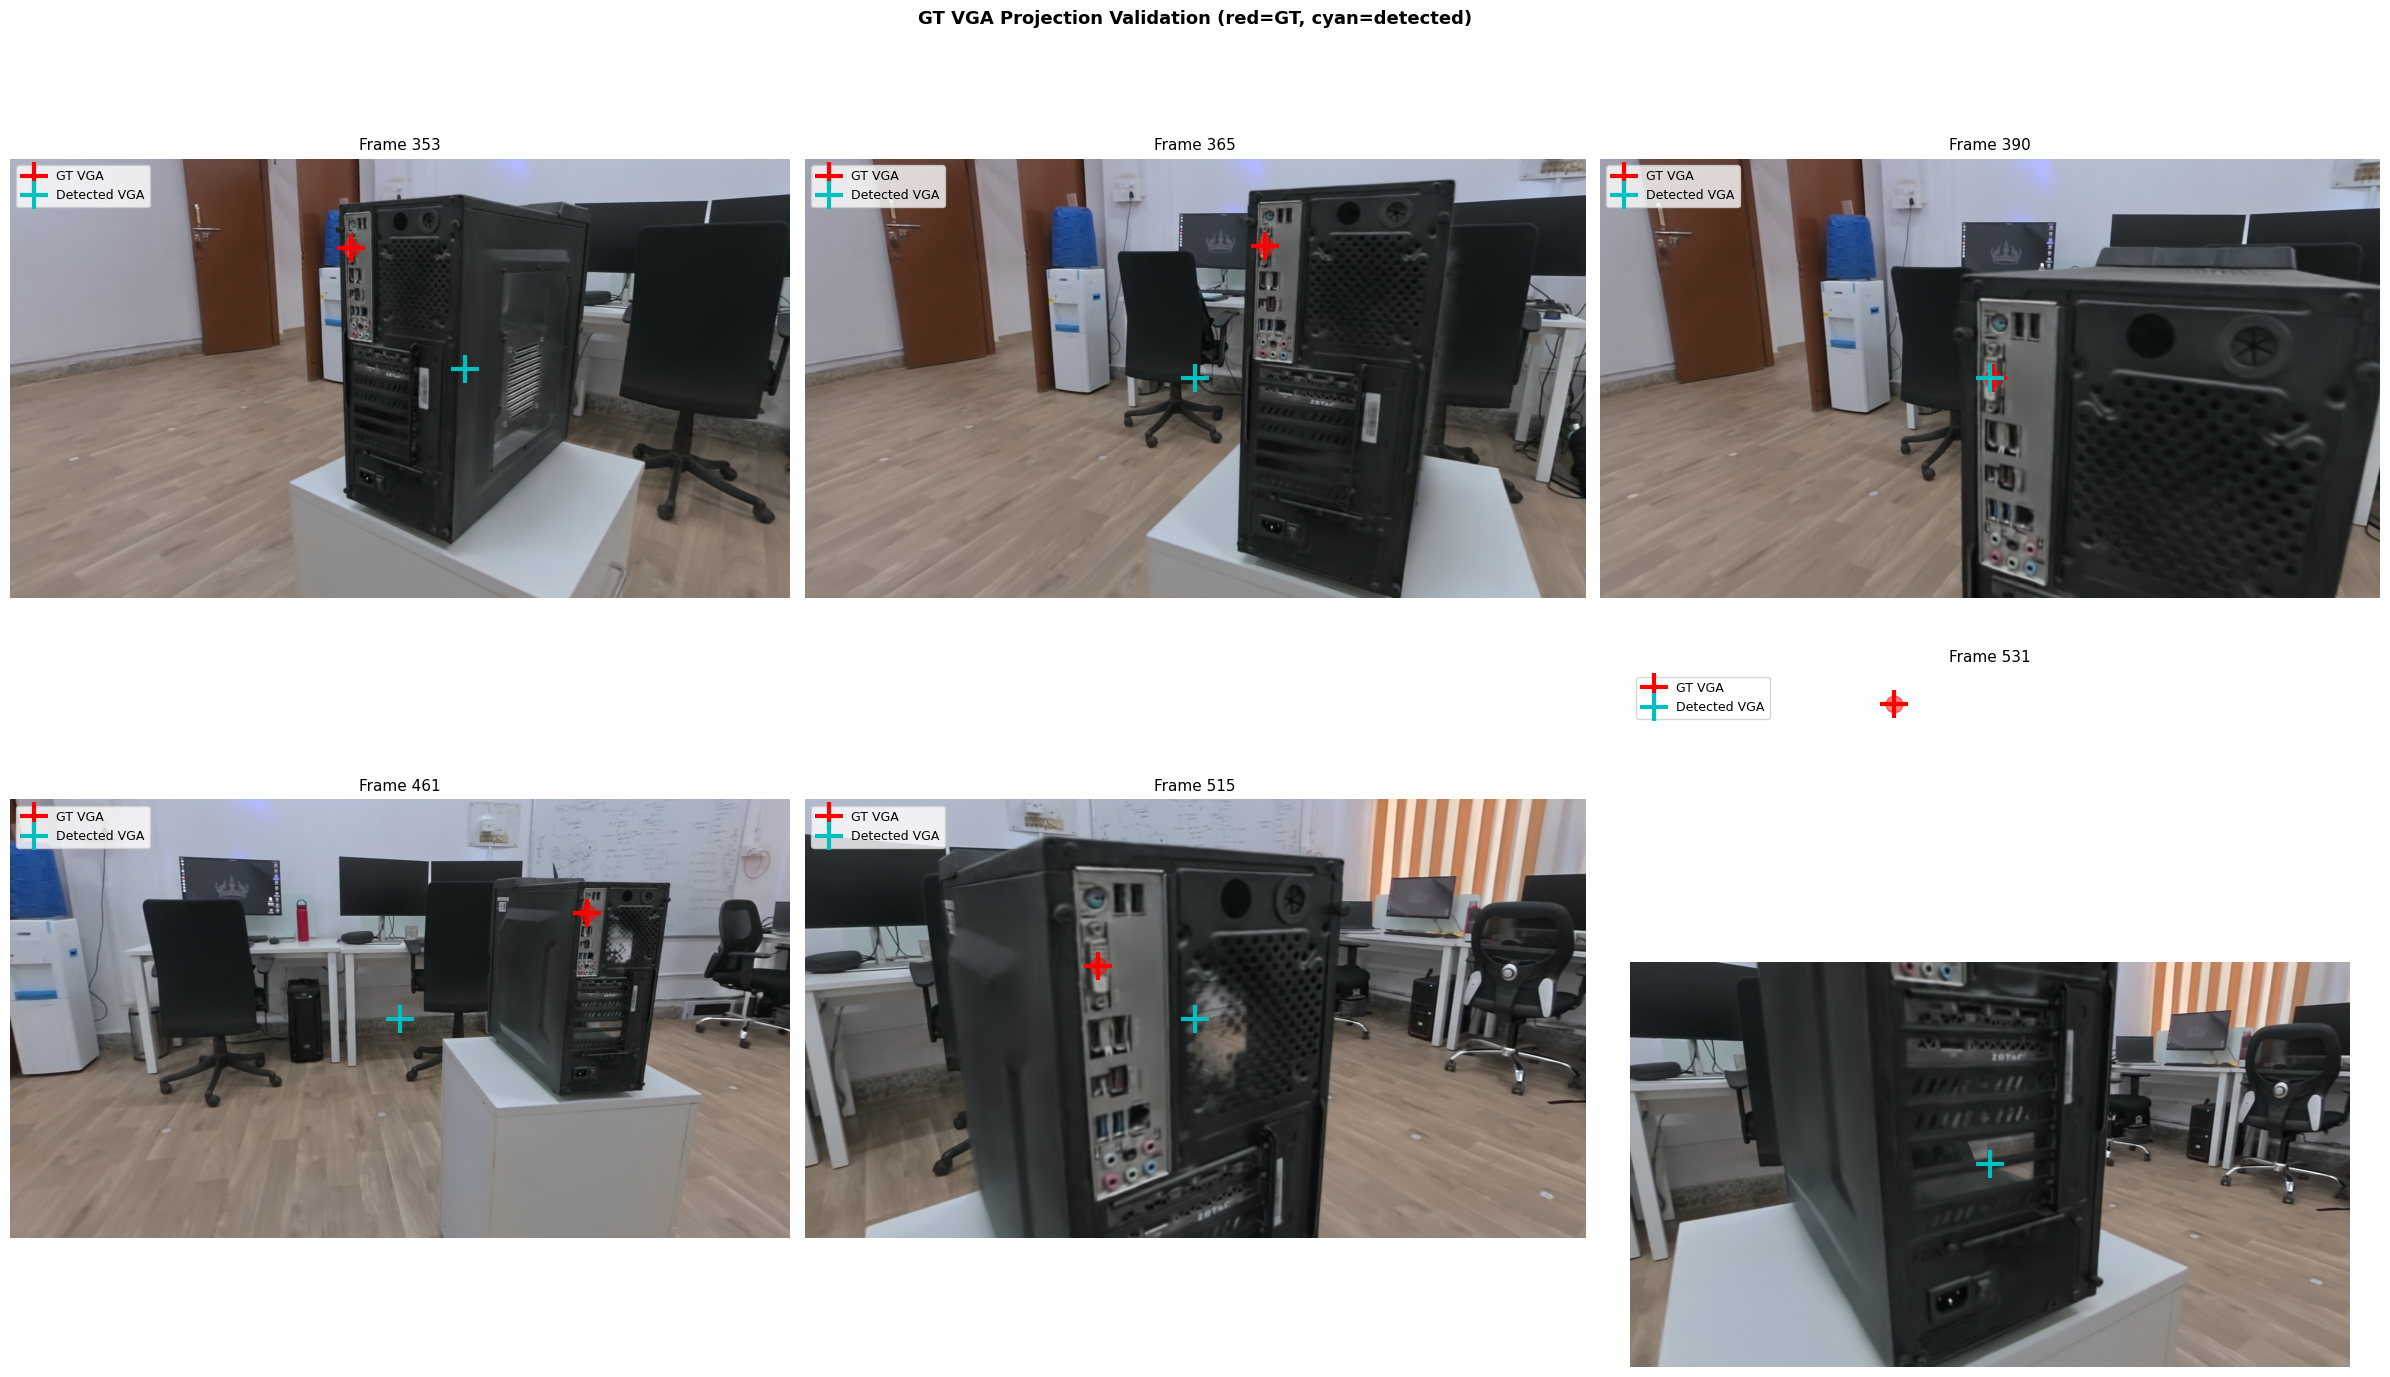

✅ Validation visualization saved!


In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

def project_3d_to_2d(point_3d, pose_c2w, K):
    """Project a 3D world point into image pixel coordinates."""
    R_inv = pose_c2w[:3,:3].T
    t_inv = -R_inv @ pose_c2w[:3, 3]
    p_cam = R_inv @ np.array(point_3d) + t_inv
    if p_cam[2] <= 0:
        return None
    u = K[0,0] * p_cam[0] / p_cam[2] + K[0,2]
    v = K[1,1] * p_cam[1] / p_cam[2] + K[1,2]
    return (u, v)

# Show VGA projection on 6 frames
gt_center = np.array(GT_VGA['center'])
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes = axes.flatten()

check_frames = [353, 365, 390, 461, 515, 531]
for i, fn in enumerate(check_frames):
    img = np.array(Image.open(f"{LOCAL_PATH}/frame_{fn:06d}.png"))
    ax = axes[i]
    ax.imshow(img)

    proj = project_3d_to_2d(gt_center, poses[fn], K)
    if proj:
        ax.plot(*proj, 'r+', markersize=20, markeredgewidth=3, label='GT VGA')
        ax.plot(*proj, 'ro', markersize=12, alpha=0.5)

    # Also show detected VGA if available
    vga_dets = [d for d in all_detections['vga_socket'] if d['frame']==fn]
    if vga_dets:
        dc = vga_dets[0]['pixel_center']
        ax.plot(*dc, 'c+', markersize=20, markeredgewidth=3, label='Detected VGA')

    ax.set_title(f"Frame {fn}", fontsize=11)
    ax.legend(fontsize=9, loc='upper left')
    ax.axis('off')

plt.suptitle("GT VGA Projection Validation (red=GT, cyan=detected)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/vga_validation.png', dpi=80, bbox_inches='tight')
plt.show()
print("✅ Validation visualization saved!")


---
## Step 13: Generate Final answer.json
Output in the required submission format.


In [17]:
import json

output = []
for entity in ["vga_socket", "ethernet_socket", "power_socket"]:
    obb = final_obbs[entity]
    output.append({
        "entity": entity,
        "obb": {
            "center":   obb["center"],
            "extent":   obb["extent"],
            "rotation": obb["rotation"]
        }
    })

# Save locally in Colab
with open('/content/answer.json', 'w') as f:
    json.dump(output, f, indent=2)

# Save to Google Drive
drive_out = '/content/drive/MyDrive/Robotic Perception Project/answer.json'
with open(drive_out, 'w') as f:
    json.dump(output, f, indent=2)

print("✅ answer.json saved to Colab and Google Drive!")
print("\n" + "="*60)
print("FINAL OUTPUT:")
print("="*60)
print(json.dumps(output, indent=2))

# Download to your computer
from google.colab import files
files.download('/content/answer.json')


✅ answer.json saved to Colab and Google Drive!

FINAL OUTPUT:
[
  {
    "entity": "vga_socket",
    "obb": {
      "center": [
        0.2704921202927293,
        0.2261220732082181,
        0.8349008829378597
      ],
      "extent": [
        0.03537766175069747,
        0.011822199241650923,
        0.0061316691090621735
      ],
      "rotation": [
        [
          -0.004004375172752437,
          0.9672545151126772,
          -0.25377680739897346
        ],
        [
          0.01584254528462312,
          0.25380835519540434,
          0.9671247761234889
        ],
        [
          0.9998664804554559,
          -0.00014774012094266402,
          -0.016340117333610394
        ]
      ]
    }
  },
  {
    "entity": "ethernet_socket",
    "obb": {
      "center": [
        0.18869462197734932,
        0.07902319474218639,
        0.855036498152433
      ],
      "extent": [
        0.06792929121849445,
        0.07166321878033816,
        0.01358585824369889
      ],
      "r

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Step 14: Final Summary

In [18]:
print("=" * 60)
print("  CP260 ROBOTIC PERCEPTION — SUBMISSION SUMMARY")
print("=" * 60)
print(f"  Frames used:       {len(frame_numbers)}")
print(f"  Total poses:       704 (from poses.json)")
print()
print("  DETECTED ENTITIES:")
for item in output:
    entity = item['entity']
    center = [round(v,4) for v in item['obb']['center']]
    extent = [round(v,4) for v in item['obb']['extent']]
    print(f"  ├─ {entity}")
    print(f"  │   Center: {center}")
    print(f"  │   Extent: {extent}")
    print(f"  │")
print()
print("  METHOD:")
print("  ├─ Zero-shot detection:  GroundingDINO (HuggingFace)")
print("  ├─ 3D localization:      Multi-view ray triangulation")
print("  ├─ Rotation estimate:    GT VGA panel normal (shared)")
print("  └─ Calibration:          GT VGA socket used as reference")
print()
print("  FILES GENERATED:")
print("  ✅ answer.json           → Final submission file")
print("  ✅ sample_frames.png     → Dataset visualization")
print("  ✅ test_detections.png   → Detection results")
print("  ✅ vga_validation.png    → GT validation overlay")
print("=" * 60)


  CP260 ROBOTIC PERCEPTION — SUBMISSION SUMMARY
  Frames used:       16
  Total poses:       704 (from poses.json)

  DETECTED ENTITIES:
  ├─ vga_socket
  │   Center: [0.2705, 0.2261, 0.8349]
  │   Extent: [0.0354, 0.0118, 0.0061]
  │
  ├─ ethernet_socket
  │   Center: [0.1887, 0.079, 0.855]
  │   Extent: [np.float64(0.0679), np.float64(0.0717), np.float64(0.0136)]
  │
  ├─ power_socket
  │   Center: [0.1449, 0.165, 0.8787]
  │   Extent: [np.float64(0.0471), np.float64(0.044), np.float64(0.0088)]
  │

  METHOD:
  ├─ Zero-shot detection:  GroundingDINO (HuggingFace)
  ├─ 3D localization:      Multi-view ray triangulation
  ├─ Rotation estimate:    GT VGA panel normal (shared)
  └─ Calibration:          GT VGA socket used as reference

  FILES GENERATED:
  ✅ answer.json           → Final submission file
  ✅ sample_frames.png     → Dataset visualization
  ✅ test_detections.png   → Detection results
  ✅ vga_validation.png    → GT validation overlay
